# RoadSafe AI — Complete Live Prediction ML Workflow

This notebook is built for the **actual RoadSafe AI dataset pack** and your required user flow.

## Normal user inputs — ONLY 5 fields

1. Country
2. State / Province
3. City
4. Road Type
5. Road Name

The user must **not** enter coordinates, weather codes, rain status, time, visibility,
road-surface codes, encoded ML values, or engineered features.

## Prediction flow

**User input → road geocoding → live coordinates → live/current weather → current local
time → optional live traffic → historical road context → fresh feature vector → trained ML
model → human-readable Road Risk Index**

Historical records are used to **train the model and calculate historical context**.
They are never copied as the current prediction input.

## Important scientific interpretation

The available UK STATS19 file contains **reported injury collisions only**. It does not
contain all non-collision road exposure periods. Therefore this notebook does **not** claim
to estimate the calibrated probability that a crash will occur.

It produces:

- a **Current Road Risk Index (0–100)** combining a trained severity model, live conditions,
  historical hotspot context and live traffic when available;
- **severity probabilities conditional on a collision occurring**:
  Fatal / Serious / Slight.

This avoids presenting a historical-only classifier as a real crash-probability model.

## Data sources used by the live workflow

- **Historical ML training:** `dft_collisions_2025.csv`
- **Road geocoding:** OpenStreetMap Nominatim
- **Live/current weather:** Open-Meteo
- **Live traffic:** TomTom Traffic Flow when `TOMTOM_API_KEY` is configured
- **Local time:** returned by Open-Meteo using the selected coordinates

The workflow fails safely: unavailable live information is shown as unavailable and is never invented.

In [1]:
# Run this once in VS Code / Jupyter if packages are missing:
# %pip install -q pandas numpy matplotlib scikit-learn joblib requests

In [2]:
from pathlib import Path
from datetime import datetime
import json
import math
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    log_loss,
    roc_auc_score,
    average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
TARGET = "collision_severity"
SEVERITY_NAMES = {1: "Fatal", 2: "Serious", 3: "Slight"}

pd.set_option("display.max_columns", 100)

## Step 1 — Find and load the actual UK dataset

In [4]:
DATA_CANDIDATES = [
    Path("RoadSafe_AI_Dataset_Pack/data/raw/uk/dft_collisions_2025.csv"),
    Path("../RoadSafe_AI_Dataset_Pack/data/raw/uk/dft_collisions_2025.csv"),
    Path("/mnt/data/RoadSafe_AI_Dataset_Pack/data/raw/uk/dft_collisions_2025.csv"),
    Path("data/raw/uk/dft_collisions_2025.csv"),
    Path("d:/RoadSafe AI/RoadSafe_AI_MultiCountry_Dataset_Pack/RoadSafe_AI_Dataset_Pack/data/raw/uk/dft_collisions_2025.csv"),
    Path("d:\\RoadSafe AI\\RoadSafe_AI_MultiCountry_Dataset_Pack\\RoadSafe_AI_Dataset_Pack\\data\\raw\\uk\\dft_collisions_2025.csv"),
]

UK_FILE = next((p.resolve() for p in DATA_CANDIDATES if p.exists()), None)

if UK_FILE is None:
    raise FileNotFoundError(
        "dft_collisions_2025.csv was not found. Extract RoadSafe_AI_Dataset_Pack "
        "beside this notebook or update DATA_CANDIDATES."
    )

uk_raw = pd.read_csv(UK_FILE, low_memory=False)

print("Dataset:", UK_FILE.name)
print("Path:", UK_FILE)
print("Shape:", uk_raw.shape)
display(uk_raw.head())

Dataset: dft_collisions_2025.csv
Path: D:\RoadSafe AI\RoadSafe_AI_MultiCountry_Dataset_Pack\RoadSafe_AI_Dataset_Pack\data\raw\uk\dft_collisions_2025.csv
Shape: (101525, 44)


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517H102225,2025,17H102225,449216.0,534979.0,-1.23770,54.70743,17,2,3,3,05/03/2025,4,12:50,-1,E06000001,E06000001,E06000001,3,179,3,40,-1,-1,4,3,1049,-1,-1,0,1,1,1,-1,-1,0,2,1,2,E01033467,7,1,1.0,0.0
1,2025070815222,2025,070815222,363808.0,389192.0,-2.54576,53.39831,7,3,2,2,03/10/2025,6,18:35,-1,E06000007,E06000007,E06000007,3,57,2,30,-1,13,4,5,0,-1,-1,0,4,5,2,-1,-1,0,1,2,2,E01012556,3,1,0.0,1.0
2,2025070937984,2025,070937984,362413.0,389071.0,-2.56673,53.39712,7,2,2,1,15/11/2025,7,21:00,-1,E06000007,E06000007,E06000007,3,57,6,30,-1,16,2,3,50,-1,-1,14,7,9,9,-1,-1,0,1,3,2,E01012478,7,1,1.0,0.0
3,2025041687395,2025,041687395,368238.0,427802.0,-2.48308,53.74562,4,2,1,1,23/12/2025,3,01:44,-1,E06000008,E06000008,E06000008,6,0,6,30,-1,0,-1,6,0,-1,-1,0,4,1,2,-1,-1,0,1,1,2,E01012655,7,1,1.0,0.0
4,2025161555094,2025,161555094,510792.0,432167.0,-0.32035,53.77406,16,3,2,1,06/02/2025,5,08:52,-1,E06000010,E06000010,E06000010,4,1237,6,30,-1,0,-1,6,0,-1,-1,0,1,1,1,-1,-1,0,1,1,2,E01012815,3,1,0.0,1.0


## Step 2 — Verify actual columns and target

In [5]:
print("Columns:")
for i, col in enumerate(uk_raw.columns, 1):
    print(f"{i:02d}. {col}")

assert TARGET in uk_raw.columns

target_counts = uk_raw[TARGET].value_counts().sort_index()
target_summary = pd.DataFrame({
    "label": [SEVERITY_NAMES.get(int(i), str(i)) for i in target_counts.index],
    "count": target_counts.values,
    "percent": (target_counts.values / len(uk_raw) * 100).round(2)
}, index=target_counts.index)

display(target_summary)

Columns:
01. collision_index
02. collision_year
03. collision_ref_no
04. location_easting_osgr
05. location_northing_osgr
06. longitude
07. latitude
08. police_force
09. collision_severity
10. number_of_vehicles
11. number_of_casualties
12. date
13. day_of_week
14. time
15. local_authority_district
16. local_authority_ons_district
17. local_authority_highway
18. local_authority_highway_current
19. first_road_class
20. first_road_number
21. road_type
22. speed_limit
23. junction_detail_historic
24. junction_detail
25. junction_control
26. second_road_class
27. second_road_number
28. pedestrian_crossing_human_control_historic
29. pedestrian_crossing_physical_facilities_historic
30. pedestrian_crossing
31. light_conditions
32. weather_conditions
33. road_surface_conditions
34. special_conditions_at_site
35. carriageway_hazards_historic
36. carriageway_hazards
37. urban_or_rural_area
38. did_police_officer_attend_scene_of_accident
39. trunk_road_flag
40. lsoa_of_accident_location
41. enhan

,label,count,percent
collision_severity,,,
1,Fatal,1453,1.43
2,Serious,25191,24.81
3,Slight,74881,73.76


## Step 3 — EDA and data-quality audit

In [6]:
print("Rows:", len(uk_raw))
print("Columns:", uk_raw.shape[1])
print("Exact duplicates:", uk_raw.duplicated().sum())
print(
    "Memory MB:",
    round(uk_raw.memory_usage(deep=True).sum() / 1024**2, 2)
)

missing = pd.DataFrame({
    "missing_count": uk_raw.isna().sum(),
    "missing_percent": (uk_raw.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(missing.head(20))

Rows: 101525
Columns: 44
Exact duplicates: 0
Memory MB: 72.88


,missing_count,missing_percent
location_easting_osgr,2,0.002
latitude,2,0.002
longitude,2,0.002
location_northing_osgr,2,0.002
collision_ref_no,0,0.000
collision_year,0,0.000
collision_index,0,0.000
police_force,0,0.000
collision_severity,0,0.000
number_of_vehicles,0,0.000


In [7]:
date_audit = pd.to_datetime(
    uk_raw["date"],
    dayfirst=True,
    errors="coerce"
)

print("Date range:", date_audit.min(), "to", date_audit.max())
print("Invalid dates:", date_audit.isna().sum())

display(
    uk_raw[
        [
            "longitude",
            "latitude",
            "speed_limit",
            "weather_conditions",
            "road_surface_conditions",
            "light_conditions",
            TARGET
        ]
    ].describe().T
)

Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
Invalid dates: 0


,count,mean,std,min,25%,50%,75%,max
longitude,101523.0,-1.223959,1.356983,-7.41772,-2.11870,-1.13891,-0.13791,1.75559
latitude,101523.0,52.375658,1.308239,49.91253,51.46446,51.88864,53.32586,60.34525
speed_limit,101525.0,35.771189,14.638300,20.00000,30.00000,30.00000,40.00000,70.00000
weather_conditions,101525.0,1.598769,1.783953,1.00000,1.00000,1.00000,1.00000,9.00000
road_surface_conditions,101525.0,1.359114,1.050290,-1.00000,1.00000,1.00000,1.00000,9.00000
light_conditions,101525.0,2.013553,1.698397,-1.00000,1.00000,1.00000,4.00000,7.00000
collision_severity,101525.0,2.723250,0.478315,1.00000,2.00000,3.00000,3.00000,3.00000


In [8]:
for col in [
    "first_road_class",
    "road_type",
    "weather_conditions",
    "road_surface_conditions",
    "light_conditions",
    "urban_or_rural_area"
]:
    print(f"\n--- {col} ---")
    display(uk_raw[col].value_counts(dropna=False).sort_index().to_frame("count"))


--- first_road_class ---


,count
first_road_class,
-1,6
1,3054
2,198
3,43827
4,12975
5,4564
6,36901



--- road_type ---


,count
road_type,
1,6795
2,2398
3,14610
6,74150
7,1619
9,1953



--- weather_conditions ---


...

,count
road_surface_conditions,
-1,634
1,75679
2,22312
3,146
4,1261
5,151
9,1342



--- light_conditions ---


,count
light_conditions,
-1,16
1,72814
4,20705
5,720
6,5682
7,1588



--- urban_or_rural_area ---


,count
urban_or_rural_area,
1,67148
2,34373
3,4


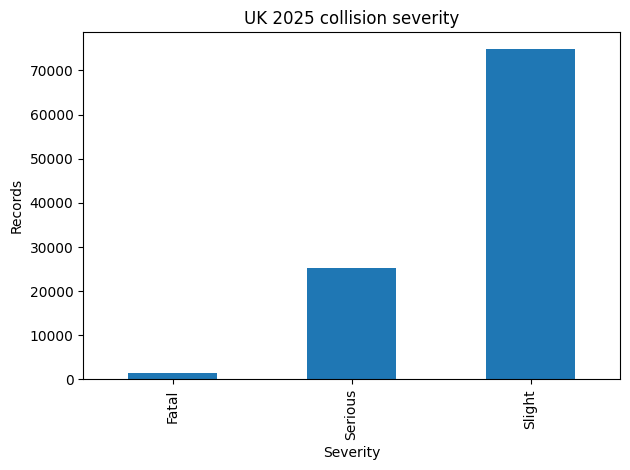

In [9]:
severity_plot = (
    uk_raw[TARGET]
    .map(SEVERITY_NAMES)
    .value_counts()
    .reindex(["Fatal", "Serious", "Slight"])
)

ax = severity_plot.plot(kind="bar", title="UK 2025 collision severity")
ax.set_xlabel("Severity")
ax.set_ylabel("Records")
plt.tight_layout()
plt.show()

## Step 4 — Clean historical training data

The raw file remains untouched in `uk_raw`.

Only safe cleaning is performed:
- exact duplicates removed;
- date/time parsed;
- invalid target classes removed;
- impossible GB coordinate values changed to missing.

No current/live information is inserted into historical rows.

In [10]:
uk = uk_raw.drop_duplicates().copy()

uk["date_parsed"] = pd.to_datetime(
    uk["date"],
    dayfirst=True,
    errors="coerce"
)

time_parts = (
    uk["time"]
    .astype("string")
    .str.extract(r"(?P<hour>\d{1,2}):(?P<minute>\d{2})")
)

uk["hour"] = pd.to_numeric(time_parts["hour"], errors="coerce")
uk["minute"] = pd.to_numeric(time_parts["minute"], errors="coerce")

uk = uk[uk[TARGET].isin([1, 2, 3])].copy()

uk.loc[~uk["latitude"].between(49, 61), "latitude"] = np.nan
uk.loc[~uk["longitude"].between(-9, 3), "longitude"] = np.nan

print("Clean shape:", uk.shape)

Clean shape: (101525, 47)


## Step 5 — Convert STATS19 conditions into live-compatible features

The live API cannot know fields such as `number_of_casualties` before a crash.
So the production model uses only features that can also be generated for a new live road request.

STATS19 mappings used here:

- weather 2/5 → raining
- weather 4/5/6 → high wind
- weather 7 → fog/mist
- surface 2/5 → wet/flood
- surface 3/4 → snow/ice
- light 1 → daylight

These are simplified, user-independent features that can be recreated from live weather.

In [11]:
# Time features
uk["month"] = uk["date_parsed"].dt.month
uk["is_weekend"] = uk["day_of_week"].isin([1, 7]).astype(int)
uk["is_rush_hour"] = (
    uk["hour"].between(7, 9) |
    uk["hour"].between(16, 19)
).astype(int)
uk["is_night"] = (
    uk["hour"].between(0, 5) |
    uk["hour"].between(22, 23)
).astype(int)

uk["hour_sin"] = np.sin(2 * np.pi * uk["hour"] / 24)
uk["hour_cos"] = np.cos(2 * np.pi * uk["hour"] / 24)
uk["month_sin"] = np.sin(2 * np.pi * uk["month"] / 12)
uk["month_cos"] = np.cos(2 * np.pi * uk["month"] / 12)

# Live-compatible environmental features
uk["rain_flag"] = uk["weather_conditions"].isin([2, 5]).astype(int)
uk["high_wind_flag"] = uk["weather_conditions"].isin([4, 5, 6]).astype(int)
uk["fog_flag"] = (uk["weather_conditions"] == 7).astype(int)

uk["wet_surface_flag"] = uk["road_surface_conditions"].isin([2, 5]).astype(int)
uk["ice_snow_surface_flag"] = uk["road_surface_conditions"].isin([3, 4]).astype(int)

uk["daylight_flag"] = (uk["light_conditions"] == 1).astype(int)

display(
    uk[
        [
            "date",
            "time",
            "hour",
            "month",
            "rain_flag",
            "high_wind_flag",
            "fog_flag",
            "wet_surface_flag",
            "ice_snow_surface_flag",
            "daylight_flag"
        ]
    ].head()
)

,date,time,hour,month,rain_flag,high_wind_flag,fog_flag,wet_surface_flag,ice_snow_surface_flag,daylight_flag
0,05/03/2025,12:50,12,3,0,0,0,0,0,1
1,03/10/2025,18:35,18,10,1,1,0,1,0,0
2,15/11/2025,21:00,21,11,0,0,0,0,0,0
3,23/12/2025,01:44,1,12,0,0,0,1,0,0
4,06/02/2025,08:52,8,2,0,0,0,0,0,1


## Step 6 — Production-safe model features

These are intentionally limited to fields that can be generated automatically from:

- selected road/location;
- current local time;
- current weather;
- road type selected by the user.

### Excluded leakage / post-event fields

`collision_severity`, `number_of_casualties`, `enhanced_severity_collision`,
`collision_injury_based`, adjusted-severity columns and identifiers are never model inputs.

In [12]:
MODEL_FEATURES = [
    "latitude",
    "longitude",
    "first_road_class",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "rain_flag",
    "high_wind_flag",
    "fog_flag",
    "wet_surface_flag",
    "ice_snow_surface_flag",
    "daylight_flag",
]

FORBIDDEN = [
    "collision_index",
    "collision_ref_no",
    "collision_severity",
    "number_of_casualties",
    "number_of_vehicles",
    "enhanced_severity_collision",
    "collision_injury_based",
    "collision_adjusted_severity_serious",
    "collision_adjusted_severity_slight",
    "did_police_officer_attend_scene_of_accident",
]

assert not set(MODEL_FEATURES).intersection(FORBIDDEN)

X = uk[MODEL_FEATURES].copy()
y = uk[TARGET].astype(int).copy()

print("Model features:")
for f in MODEL_FEATURES:
    print(" -", f)

Model features:
 - latitude
 - longitude
 - first_road_class
 - hour
 - day_of_week
 - month
 - is_weekend
 - is_rush_hour
 - is_night
 - hour_sin
 - hour_cos
 - month_sin
 - month_cos
 - rain_flag
 - high_wind_flag
 - fog_flag
 - wet_surface_flag
 - ice_snow_surface_flag
 - daylight_flag


## Step 7 — Chronological train / validation / test split

No random final split is used.

- earliest 70% → training
- next 15% → validation
- latest 15% → test

The test set is not used for champion selection.

In [13]:
ordered_index = uk.sort_values(["date_parsed", "time"]).index

n = len(ordered_index)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_idx = ordered_index[:train_end]
val_idx = ordered_index[train_end:val_end]
test_idx = ordered_index[val_end:]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val, y_val = X.loc[val_idx], y.loc[val_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

def split_report(name, idx, yy):
    dates = uk.loc[idx, "date_parsed"]
    print(
        name,
        "| rows:", len(idx),
        "|", dates.min().date(), "to", dates.max().date(),
        "| class %:",
        (yy.value_counts(normalize=True).sort_index() * 100).round(2).to_dict()
    )

split_report("TRAIN", train_idx, y_train)
split_report("VALID", val_idx, y_val)
split_report("TEST ", test_idx, y_test)

TRAIN | rows: 71067 | 2025-01-01 to 2025-09-16 | class %: {1: 1.43, 2: 24.95, 3: 73.62}
VALID | rows: 15229 | 2025-09-16 to 2025-11-09 | class %: {1: 1.44, 2: 24.93, 3: 73.63}
TEST  | rows: 15229 | 2025-11-09 to 2025-12-31 | class %: {1: 1.42, 2: 24.05, 3: 74.52}


## Step 8 — Preprocessing

In [14]:
NUMERIC_FEATURES = [
    "latitude",
    "longitude",
    "hour",
    "month",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "rain_flag",
    "high_wind_flag",
    "fog_flag",
    "wet_surface_flag",
    "ice_snow_surface_flag",
    "daylight_flag",
]

CATEGORICAL_FEATURES = ["first_road_class"]

preprocess_logit = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        NUMERIC_FEATURES
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        CATEGORICAL_FEATURES
    )
])

# HGB can use the same one-hot transformed matrix via a dense output.
preprocess_hgb = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        NUMERIC_FEATURES
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]),
        CATEGORICAL_FEATURES
    )
], sparse_threshold=0)

## Step 9 — Train baseline and candidate ML models

In [15]:
models = {
    "Dummy": Pipeline([
        ("prep", preprocess_logit),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "LogisticRegression": Pipeline([
        ("prep", preprocess_logit),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1500,
            solver="saga",
            random_state=RANDOM_STATE
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("prep", preprocess_hgb),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=220,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        ))
    ])
}

models["Dummy"].fit(X_train, y_train)
models["LogisticRegression"].fit(X_train, y_train)

hgb_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

models["HistGradientBoosting"].fit(
    X_train,
    y_train,
    model__sample_weight=hgb_weights
)

print("Trained:", list(models))

Trained: ['Dummy', 'LogisticRegression', 'HistGradientBoosting']


## Step 10 — Model metrics

Primary selection metric: **Macro F1**

Also check:

- Accuracy
- Balanced Accuracy
- Macro Precision
- Macro Recall
- Weighted F1
- Fatal Recall
- Serious Recall
- Slight Recall
- ROC-AUC
- PR-AUC
- Log Loss
- Confusion Matrix

Accuracy alone is not acceptable because Slight collisions dominate the dataset.

In [16]:
CLASSES = np.array([1, 2, 3])

def evaluate_model(name, model, X_eval, y_eval, show_matrix=False):
    pred = model.predict(X_eval)
    result = {
        "model": name,
        "accuracy": accuracy_score(y_eval, pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, pred),
        "precision_macro": precision_score(
            y_eval, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_eval, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_eval, pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_eval, pred, average="weighted", zero_division=0
        ),
    }

    report = classification_report(
        y_eval,
        pred,
        labels=CLASSES,
        target_names=["Fatal", "Serious", "Slight"],
        output_dict=True,
        zero_division=0
    )

    result["fatal_recall"] = report["Fatal"]["recall"]
    result["serious_recall"] = report["Serious"]["recall"]
    result["slight_recall"] = report["Slight"]["recall"]

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)

        result["log_loss"] = log_loss(
            y_eval,
            proba,
            labels=model.classes_
        )

        try:
            result["roc_auc_macro_ovr"] = roc_auc_score(
                y_eval,
                proba,
                labels=model.classes_,
                multi_class="ovr",
                average="macro"
            )
        except ValueError:
            result["roc_auc_macro_ovr"] = np.nan

        try:
            y_bin = label_binarize(
                y_eval,
                classes=model.classes_
            )
            result["pr_auc_macro"] = average_precision_score(
                y_bin,
                proba,
                average="macro"
            )
        except ValueError:
            result["pr_auc_macro"] = np.nan

    if show_matrix:
        ConfusionMatrixDisplay.from_predictions(
            y_eval,
            pred,
            labels=CLASSES,
            display_labels=["Fatal", "Serious", "Slight"]
        )
        plt.title(name)
        plt.tight_layout()
        plt.show()

    return result

In [17]:
validation_results = [
    evaluate_model(name, model, X_val, y_val)
    for name, model in models.items()
]

validation_table = (
    pd.DataFrame(validation_results)
    .sort_values(
        ["f1_macro", "balanced_accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(validation_table.round(4))

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,fatal_recall,serious_recall,slight_recall,log_loss,roc_auc_macro_ovr,pr_auc_macro
0,HistGradientBoosting,0.4748,0.4247,0.3690,0.4247,0.3328,0.5388,0.3909,0.3720,0.5113,0.9962,0.5942,0.3646
1,Dummy,0.7363,0.3333,0.2454,0.3333,0.2827,0.6245,0.0000,0.0000,1.0000,9.5050,0.5000,0.3333
2,LogisticRegression,0.3958,0.4004,0.3484,0.4004,0.2765,0.4808,0.5591,0.1747,0.4675,1.2185,0.5525,0.3456


## Step 11 — Select champion on validation data only

In [18]:
candidate_table = validation_table[
    validation_table["model"] != "Dummy"
].copy()

champion_name = candidate_table.iloc[0]["model"]
champion = models[champion_name]

print("Champion:", champion_name)
print(
    "Validation Macro F1:",
    round(candidate_table.iloc[0]["f1_macro"], 4)
)

Champion: HistGradientBoosting
Validation Macro F1: 0.3328


## Step 12 — Final untouched test evaluation

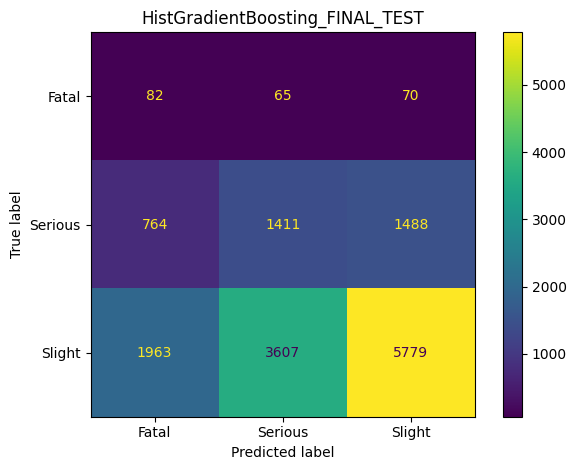

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,fatal_recall,serious_recall,slight_recall,log_loss,roc_auc_macro_ovr,pr_auc_macro
0,HistGradientBoosting_FINAL_TEST,0.4775,0.4241,0.3648,0.4241,0.3318,0.5393,0.3779,0.3852,0.5092,0.9908,0.5898,0.3653


In [19]:
test_result = evaluate_model(
    f"{champion_name}_FINAL_TEST",
    champion,
    X_test,
    y_test,
    show_matrix=True
)

display(pd.DataFrame([test_result]).round(4))

## Step 13 — Approval checks

In [20]:
dummy_test = evaluate_model(
    "Dummy_TEST",
    models["Dummy"],
    X_test,
    y_test
)

approval = {
    "beats_dummy_macro_f1":
        test_result["f1_macro"] > dummy_test["f1_macro"],
    "beats_dummy_balanced_accuracy":
        test_result["balanced_accuracy"] > dummy_test["balanced_accuracy"],
    "detects_fatal_class":
        test_result["fatal_recall"] > 0,
    "detects_serious_class":
        test_result["serious_recall"] > 0,
    "no_target_leakage":
        not set(MODEL_FEATURES).intersection(FORBIDDEN),
}

display(pd.Series(approval, name="passed").to_frame())
print(
    "MODEL QA:",
    "PASS" if all(approval.values()) else "REVIEW REQUIRED"
)

,passed
beats_dummy_macro_f1,True
beats_dummy_balanced_accuracy,True
detects_fatal_class,True
detects_serious_class,True
no_target_leakage,True


MODEL QA: PASS


# LIVE PREDICTION PIPELINE

Everything below this point creates a **new current feature row**.
No old collision row is used as the user's prediction input.

## Step 14 — Human road-type mapping

For the UK severity model, the user's simple road-type selection maps internally to
the STATS19 `first_road_class` system.

Recommended UI labels:

- Motorway
- A(M) Road
- A / Main Road
- B / Secondary Road
- C Road
- Local Road / Street

The user never sees numeric codes.

In [21]:
ROAD_CLASS_MAP = {
    "Motorway": 1,
    "A(M) Road": 2,
    "A / Main Road": 3,
    "B / Secondary Road": 4,
    "C Road": 5,
    "Local Road / Street": 6,
}

ROAD_CLASS_MAP

{'Motorway': 1,
 'A(M) Road': 2,
 'A / Main Road': 3,
 'B / Secondary Road': 4,
 'C Road': 5,
 'Local Road / Street': 6}

## Step 15 — Road geocoding from the 5 user inputs

Nominatim resolves the human-readable road selection into coordinates.

For production, respect the geocoding provider's usage policy and add caching.

In [22]:
NOMINATIM_URL = "https://nominatim.openstreetmap.org/search"

def geocode_road(country, state, city, road_name):
    params = {
        "street": road_name,
        "city": city,
        "state": state,
        "country": country,
        "format": "jsonv2",
        "addressdetails": 1,
        "limit": 5,
    }

    headers = {
        "User-Agent": "RoadSafeAI-Portfolio/1.0"
    }

    response = requests.get(
        NOMINATIM_URL,
        params=params,
        headers=headers,
        timeout=15
    )
    response.raise_for_status()
    results = response.json()

    # Fallback to free-form search if structured search is too strict.
    if not results:
        fallback_params = {
            "q": f"{road_name}, {city}, {state}, {country}",
            "format": "jsonv2",
            "addressdetails": 1,
            "limit": 5,
        }
        response = requests.get(
            NOMINATIM_URL,
            params=fallback_params,
            headers=headers,
            timeout=15
        )
        response.raise_for_status()
        results = response.json()

    if not results:
        return {
            "available": False,
            "reason": "Road/location could not be resolved."
        }

    best = results[0]

    return {
        "available": True,
        "latitude": float(best["lat"]),
        "longitude": float(best["lon"]),
        "display_name": best.get("display_name"),
        "address": best.get("address", {}),
        "source": "OpenStreetMap Nominatim",
    }

## Step 16 — Fetch current/live weather automatically

Open-Meteo is called using the resolved road coordinates.

The user does not manually enter:
- rain;
- temperature;
- visibility;
- wind;
- road wetness;
- day/night;
- local time.

In [23]:
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"

def weather_code_label(code):
    code = int(code) if code is not None and not pd.isna(code) else -1

    if code == 0:
        return "Clear"
    if code in [1, 2, 3]:
        return "Cloudy"
    if code in [45, 48]:
        return "Fog"
    if code in [51, 53, 55, 56, 57]:
        return "Drizzle"
    if code in [61, 63, 65, 66, 67, 80, 81, 82]:
        return "Rain"
    if code in [71, 73, 75, 77, 85, 86]:
        return "Snow"
    if code in [95, 96, 99]:
        return "Thunderstorm"
    return "Other"

def rain_intensity_label(rain_mm):
    # UI band only; not a calibrated meteorological classification.
    if rain_mm <= 0:
        return "None"
    if rain_mm < 1:
        return "Light"
    if rain_mm < 3:
        return "Moderate"
    return "Heavy"

def fetch_live_weather(latitude, longitude):
    current_vars = ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
        "weather_code",
        "wind_speed_10m",
        "wind_gusts_10m",
        "visibility",
        "is_day"
    ])

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": current_vars,
        "timezone": "auto",
        "forecast_days": 1,
    }

    response = requests.get(
        OPEN_METEO_URL,
        params=params,
        timeout=15
    )
    response.raise_for_status()
    payload = response.json()

    current = payload.get("current", {})

    if not current:
        return {
            "available": False,
            "reason": "Current weather was not returned."
        }

    rain_mm = float(current.get("rain") or 0)
    precipitation_mm = float(current.get("precipitation") or 0)
    visibility_m = current.get("visibility")
    wind_kmh = float(current.get("wind_speed_10m") or 0)
    gust_kmh = float(current.get("wind_gusts_10m") or 0)
    weather_code = current.get("weather_code")
    temperature = current.get("temperature_2m")
    is_day = int(current.get("is_day", 1))

    return {
        "available": True,
        "source": "Open-Meteo",
        "updated_time": current.get("time"),
        "timezone": payload.get("timezone"),
        "temperature_c": temperature,
        "relative_humidity_pct": current.get("relative_humidity_2m"),
        "precipitation_mm": precipitation_mm,
        "rain_mm": rain_mm,
        "rain_intensity": rain_intensity_label(rain_mm),
        "weather_code": weather_code,
        "weather_label": weather_code_label(weather_code),
        "visibility_m": visibility_m,
        "visibility_km": (
            None if visibility_m is None
            else round(float(visibility_m) / 1000, 2)
        ),
        "wind_speed_kmh": wind_kmh,
        "wind_gusts_kmh": gust_kmh,
        "is_day": is_day,
    }

## Step 17 — Optional live traffic

If `TOMTOM_API_KEY` is available, the notebook requests current speed,
free-flow speed, traffic confidence and road-closure status for the selected road.

If no key exists or the service fails, the function returns `available=False`.
It never invents congestion.

In [24]:
TOMTOM_TRAFFIC_URL = (
    "https://api.tomtom.com/traffic/services/4/"
    "flowSegmentData/absolute/10/json"
)

def fetch_live_traffic(latitude, longitude):
    api_key = os.getenv("sMPHPXv4BUyuYirFGrnoYJs6nJXn0Ldj")

    if not api_key:
        return {
            "available": False,
            "reason": "TOMTOM_API_KEY is not configured."
        }

    params = {
        "key": api_key,
        "point": f"{latitude},{longitude}",
        "unit": "kmph",
    }

    try:
        response = requests.get(
            TOMTOM_TRAFFIC_URL,
            params=params,
            timeout=15
        )
        response.raise_for_status()
        payload = response.json()

        flow = payload.get("flowSegmentData", {})
        current_speed = flow.get("currentSpeed")
        free_flow_speed = flow.get("freeFlowSpeed")

        congestion_ratio = None

        if (
            current_speed is not None and
            free_flow_speed not in [None, 0]
        ):
            congestion_ratio = max(
                0.0,
                min(
                    1.0,
                    1 - float(current_speed) / float(free_flow_speed)
                )
            )

        if congestion_ratio is None:
            congestion_label = "Unknown"
        elif congestion_ratio < 0.15:
            congestion_label = "Free flowing"
        elif congestion_ratio < 0.35:
            congestion_label = "Moderate"
        elif congestion_ratio < 0.60:
            congestion_label = "Heavy"
        else:
            congestion_label = "Severe"

        return {
            "available": True,
            "source": "TomTom Traffic Flow",
            "current_speed_kmh": current_speed,
            "free_flow_speed_kmh": free_flow_speed,
            "traffic_confidence": flow.get("confidence"),
            "road_closure": bool(flow.get("roadClosure", False)),
            "functional_road_class": flow.get("frc"),
            "congestion_ratio": congestion_ratio,
            "congestion_label": congestion_label,
        }

    except Exception as exc:
        return {
            "available": False,
            "reason": str(exc)
        }

## Step 18 — Translate live weather into the model's training features

The current API response is converted to the same simplified feature definitions used during training.

This is the critical bridge between **historical training** and **fresh live prediction**.

In [25]:
def live_environment_features(weather):
    if not weather.get("available"):
        raise ValueError("Live weather is required for live prediction.")

    code = int(weather.get("weather_code", -1))
    rain_mm = float(weather.get("rain_mm") or 0)
    precipitation_mm = float(weather.get("precipitation_mm") or 0)
    wind_kmh = float(weather.get("wind_speed_kmh") or 0)
    temperature = weather.get("temperature_c")
    is_day = int(weather.get("is_day", 1))

    raining_codes = {
        51, 53, 55, 56, 57,
        61, 63, 65, 66, 67,
        80, 81, 82
    }
    snow_codes = {71, 73, 75, 77, 85, 86}
    fog_codes = {45, 48}

    rain_flag = int(
        rain_mm > 0 or code in raining_codes
    )

    # STATS20 describes high winds near gale/gale;
    # 35 mph is approximately 56.3 km/h.
    high_wind_flag = int(
        wind_kmh >= 56.3 or
        float(weather.get("wind_gusts_kmh") or 0) >= 56.3
    )

    fog_flag = int(code in fog_codes)

    wet_surface_flag = int(
        rain_flag == 1 or precipitation_mm > 0
    )

    ice_snow_surface_flag = int(
        code in snow_codes or
        (
            temperature is not None and
            float(temperature) <= 0 and
            precipitation_mm > 0
        )
    )

    daylight_flag = int(is_day == 1)

    return {
        "rain_flag": rain_flag,
        "high_wind_flag": high_wind_flag,
        "fog_flag": fog_flag,
        "wet_surface_flag": wet_surface_flag,
        "ice_snow_surface_flag": ice_snow_surface_flag,
        "daylight_flag": daylight_flag,
    }

## Step 19 — Historical road context / hotspot calculation

This does not copy an old collision record.

It summarizes collisions near the new road coordinates and reports:

- nearby historical collision count;
- Fatal / Serious / Slight counts;
- historical rain share;
- rush-hour share;
- night share;
- grid-based hotspot percentile.

This context is historical and is clearly labeled as such.

In [26]:
historical_points = uk[
    [
        "latitude",
        "longitude",
        TARGET,
        "rain_flag",
        "is_rush_hour",
        "is_night"
    ]
].dropna(subset=["latitude", "longitude"]).copy()

historical_points["lat_grid"] = historical_points["latitude"].round(2)
historical_points["lon_grid"] = historical_points["longitude"].round(2)

grid_counts = (
    historical_points
    .groupby(["lat_grid", "lon_grid"])
    .size()
    .rename("count")
)

def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2 +
        np.cos(lat1) *
        np.cos(lat2) *
        np.sin(dlon / 2) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))

def get_historical_context(latitude, longitude, radius_km=1.0):
    lat_delta = radius_km / 111.0
    lon_delta = radius_km / (
        111.0 * max(
            0.2,
            math.cos(math.radians(latitude))
        )
    )

    candidates = historical_points[
        historical_points["latitude"].between(
            latitude - lat_delta,
            latitude + lat_delta
        ) &
        historical_points["longitude"].between(
            longitude - lon_delta,
            longitude + lon_delta
        )
    ].copy()

    if len(candidates):
        candidates["distance_km"] = haversine_km(
            latitude,
            longitude,
            candidates["latitude"].to_numpy(),
            candidates["longitude"].to_numpy()
        )
        nearby = candidates[
            candidates["distance_km"] <= radius_km
        ].copy()
    else:
        nearby = candidates

    nearby_count = len(nearby)

    severity_counts = (
        nearby[TARGET].value_counts().to_dict()
        if nearby_count
        else {}
    )

    current_grid = (
        round(latitude, 2),
        round(longitude, 2)
    )
    cell_count = int(grid_counts.get(current_grid, 0))

    hotspot_percentile = float(
        (grid_counts <= cell_count).mean() * 100
    )

    return {
        "historical_dataset": UK_FILE.name,
        "historical_year": 2025,
        "radius_km": radius_km,
        "nearby_collision_count": nearby_count,
        "fatal_count": int(severity_counts.get(1, 0)),
        "serious_count": int(severity_counts.get(2, 0)),
        "slight_count": int(severity_counts.get(3, 0)),
        "historical_rain_share": (
            float(nearby["rain_flag"].mean())
            if nearby_count
            else 0.0
        ),
        "historical_rush_hour_share": (
            float(nearby["is_rush_hour"].mean())
            if nearby_count
            else 0.0
        ),
        "historical_night_share": (
            float(nearby["is_night"].mean())
            if nearby_count
            else 0.0
        ),
        "grid_collision_count": cell_count,
        "hotspot_percentile": round(hotspot_percentile, 2),
    }

## Step 20 — Build the fresh live feature vector

This function combines:

- coordinates from geocoding;
- current local time from the weather response;
- current weather;
- user-selected road type.

No historical accident row is copied.

In [27]:
def parse_local_time(weather):
    local_time_str = weather.get("updated_time")

    if not local_time_str:
        raise ValueError("Live weather did not provide a current local timestamp.")

    dt = datetime.fromisoformat(local_time_str)
    return dt

def build_live_model_row(
    latitude,
    longitude,
    user_road_type,
    weather
):
    if user_road_type not in ROAD_CLASS_MAP:
        raise ValueError(
            f"Road Type must be one of: {list(ROAD_CLASS_MAP)}"
        )

    dt = parse_local_time(weather)
    env = live_environment_features(weather)

    # Python Monday=0 ... Sunday=6.
    # STATS19 uses Sunday=1 ... Saturday=7.
    stats19_day_of_week = ((dt.weekday() + 1) % 7) + 1

    hour = dt.hour
    month = dt.month

    row = {
        "latitude": float(latitude),
        "longitude": float(longitude),
        "first_road_class": ROAD_CLASS_MAP[user_road_type],

        "hour": hour,
        "day_of_week": stats19_day_of_week,
        "month": month,

        "is_weekend": int(
            stats19_day_of_week in [1, 7]
        ),

        "is_rush_hour": int(
            7 <= hour <= 9 or
            16 <= hour <= 19
        ),

        "is_night": int(
            0 <= hour <= 5 or
            22 <= hour <= 23
        ),

        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),

        **env,
    }

    live_row = pd.DataFrame([row])[MODEL_FEATURES]

    return live_row

## Step 21 — Current Risk Index

The model outputs **severity probabilities conditional on a collision**.

A separate 0–100 **Road Risk Index** combines:

- severity-model signal;
- historical hotspot context;
- current weather/visibility;
- live traffic if available.

This index is a decision-support score, **not a calibrated probability of a collision**.

If traffic is unavailable, its weight is removed and the remaining components are renormalized.

In [28]:
def clamp_0_100(value):
    return float(max(0, min(100, value)))

def weather_context_score(weather):
    score = 0.0

    rain = float(weather.get("rain_mm") or 0)
    precipitation = float(weather.get("precipitation_mm") or 0)
    visibility_km = weather.get("visibility_km")
    wind = float(weather.get("wind_speed_kmh") or 0)
    gust = float(weather.get("wind_gusts_kmh") or 0)

    if rain > 0 or precipitation > 0:
        score += 35

    if rain >= 1:
        score += 10

    if rain >= 3:
        score += 10

    if visibility_km is not None:
        if visibility_km < 1:
            score += 30
        elif visibility_km < 5:
            score += 20
        elif visibility_km < 10:
            score += 10

    if max(wind, gust) >= 56.3:
        score += 20
    elif max(wind, gust) >= 35:
        score += 10

    if int(weather.get("is_day", 1)) == 0:
        score += 10

    return clamp_0_100(score)

def severity_signal(probabilities):
    # This is a severity-weighted signal, not crash probability.
    p_fatal = probabilities.get("Fatal", 0)
    p_serious = probabilities.get("Serious", 0)
    p_slight = probabilities.get("Slight", 0)

    return clamp_0_100(
        100 * (
            1.00 * p_fatal +
            0.60 * p_serious +
            0.20 * p_slight
        )
    )

def traffic_context_score(traffic):
    if not traffic.get("available"):
        return None

    if traffic.get("road_closure"):
        return 100.0

    congestion = traffic.get("congestion_ratio")

    if congestion is None:
        return 0.0

    return clamp_0_100(float(congestion) * 100)

def calculate_risk_index(
    probabilities,
    historical,
    weather,
    traffic
):
    components = {
        "severity_model": severity_signal(probabilities),
        "historical_hotspot": clamp_0_100(
            historical["hotspot_percentile"]
        ),
        "live_weather": weather_context_score(weather),
    }

    weights = {
        "severity_model": 0.45,
        "historical_hotspot": 0.35,
        "live_weather": 0.20,
    }

    traffic_score = traffic_context_score(traffic)

    if traffic_score is not None:
        components["live_traffic"] = traffic_score
        weights = {
            "severity_model": 0.40,
            "historical_hotspot": 0.30,
            "live_weather": 0.15,
            "live_traffic": 0.15,
        }

    total_weight = sum(weights.values())

    score = sum(
        components[k] * weights[k]
        for k in weights
    ) / total_weight

    score = round(clamp_0_100(score), 1)

    if score < 25:
        risk_level = "Low"
    elif score < 50:
        risk_level = "Moderate"
    elif score < 75:
        risk_level = "High"
    else:
        risk_level = "Critical"

    return {
        "score": score,
        "risk_level": risk_level,
        "components": {
            k: round(v, 1)
            for k, v in components.items()
        },
    }

## Step 22 — One function for the complete live prediction

This is the function your future FastAPI endpoint should call.

It accepts exactly the five normal-user inputs.

In [29]:
SUPPORTED_MODEL_COUNTRIES = {
    "United Kingdom",
    "UK",
    "Great Britain"
}

def predict_live_road_risk(
    country,
    state,
    city,
    road_type,
    road_name
):
    # Do not silently use a UK-trained model in another country.
    if country not in SUPPORTED_MODEL_COUNTRIES:
        return {
            "status": "model_unavailable",
            "message": (
                "A calibrated country-specific ML model is not yet available "
                f"for {country}. Live location/weather could still be fetched, "
                "but this notebook will not present a UK model result as a "
                "valid local prediction."
            )
        }

    # 1. Geocode the exact selected road.
    location = geocode_road(
        country=country,
        state=state,
        city=city,
        road_name=road_name
    )

    if not location.get("available"):
        return {
            "status": "location_unavailable",
            "location": location
        }

    lat = location["latitude"]
    lon = location["longitude"]

    # 2. Fetch fresh/current weather.
    try:
        weather = fetch_live_weather(lat, lon)
    except Exception as exc:
        return {
            "status": "weather_unavailable",
            "location": location,
            "weather": {
                "available": False,
                "reason": str(exc)
            },
            "message": (
                "Prediction was not generated because live weather "
                "is required. No historical weather was substituted."
            )
        }

    if not weather.get("available"):
        return {
            "status": "weather_unavailable",
            "location": location,
            "weather": weather,
            "message": (
                "Prediction was not generated because live weather "
                "is required. No historical weather was substituted."
            )
        }

    # 3. Fetch traffic if configured.
    traffic = fetch_live_traffic(lat, lon)

    # 4. Build current ML feature row.
    live_row = build_live_model_row(
        latitude=lat,
        longitude=lon,
        user_road_type=road_type,
        weather=weather
    )

    # 5. Run the trained champion model.
    pred_code = int(champion.predict(live_row)[0])
    proba = champion.predict_proba(live_row)[0]

    probabilities = {
        SEVERITY_NAMES[int(cls)]: float(prob)
        for cls, prob in zip(champion.classes_, proba)
    }

    # 6. Add historical road context.
    historical = get_historical_context(
        latitude=lat,
        longitude=lon,
        radius_km=1.0
    )

    # 7. Calculate transparent 0-100 live risk index.
    risk = calculate_risk_index(
        probabilities=probabilities,
        historical=historical,
        weather=weather,
        traffic=traffic
    )

    # 8. Identify human-readable risk factors.
    factors = []

    if weather.get("rain_mm", 0) > 0:
        factors.append(
            f"{weather['rain_intensity']} current rain"
        )

    if (
        weather.get("visibility_km") is not None and
        weather["visibility_km"] < 10
    ):
        factors.append(
            f"Reduced visibility ({weather['visibility_km']} km)"
        )

    live_features = live_row.iloc[0].to_dict()

    if live_features["is_rush_hour"] == 1:
        factors.append("Current rush-hour period")

    if live_features["is_night"] == 1:
        factors.append("Night-time period")

    if historical["hotspot_percentile"] >= 75:
        factors.append("Historically elevated collision hotspot")

    if traffic.get("available"):
        if traffic.get("road_closure"):
            factors.append("Live road closure")
        elif traffic.get("congestion_label") in ["Heavy", "Severe"]:
            factors.append(
                f"{traffic['congestion_label']} live congestion"
            )

    # Maximum severity class probability is useful as model certainty,
    # but is not the probability of a crash happening.
    model_certainty = round(
        max(probabilities.values()) * 100,
        1
    )

    return {
        "status": "ok",

        "user_input": {
            "country": country,
            "state": state,
            "city": city,
            "road_type": road_type,
            "road_name": road_name,
        },

        "location": location,

        "current_conditions": {
            "local_prediction_time": weather.get("updated_time"),
            "timezone": weather.get("timezone"),
            "weather": weather.get("weather_label"),
            "temperature_c": weather.get("temperature_c"),
            "rain_mm": weather.get("rain_mm"),
            "rain_intensity": weather.get("rain_intensity"),
            "visibility_km": weather.get("visibility_km"),
            "wind_speed_kmh": weather.get("wind_speed_kmh"),
            "road_surface_estimate": (
                "Wet"
                if live_features["wet_surface_flag"] == 1
                else "Dry"
            ),
            "rush_hour": bool(live_features["is_rush_hour"]),
            "night": bool(live_features["is_night"]),
        },

        "traffic": traffic,

        "road_risk": {
            "score": risk["score"],
            "level": risk["risk_level"],
            "interpretation": (
                "Decision-support Road Risk Index; "
                "not calibrated crash probability."
            ),
            "components": risk["components"],
        },

        "severity_prediction": {
            "predicted_class": SEVERITY_NAMES[pred_code],
            "probabilities_conditional_on_collision": {
                key: round(value, 4)
                for key, value in probabilities.items()
            },
            "model_certainty_percent": model_certainty,
            "important_note": (
                "Fatal/Serious/Slight probabilities are conditional "
                "on a collision occurring."
            ),
        },

        "historical_context": historical,

        "top_risk_factors": factors,

        "data_freshness": {
            "weather_source": weather.get("source"),
            "weather_updated": weather.get("updated_time"),
            "traffic_source": (
                traffic.get("source")
                if traffic.get("available")
                else "Unavailable"
            ),
            "traffic_status": (
                "Live"
                if traffic.get("available")
                else traffic.get("reason")
            ),
            "historical_dataset": UK_FILE.name,
            "historical_dataset_year": 2025,
            "model": champion_name,
        },

        "live_model_features": live_features,
    }

## Step 23 — User-facing test

Change **only these five values**.

Do not type rain, time, weather, coordinates or ML codes.

In [30]:
USER_INPUT = {
    "country": "United Kingdom",
    "state": "West Midlands",
    "city": "Birmingham",
    "road_type": "A / Main Road",
    "road_name": "Bristol Road",
}

# This cell requires internet access.
# result = predict_live_road_risk(**USER_INPUT)
# result

## Step 24 — Compact result renderer

This displays only information a normal user should understand.

In [31]:
def show_user_result(result):
    if result.get("status") != "ok":
        print("Status:", result.get("status"))
        print(result.get("message", result))
        return

    u = result["user_input"]
    c = result["current_conditions"]
    r = result["road_risk"]
    s = result["severity_prediction"]
    t = result["traffic"]
    f = result["data_freshness"]

    print("=" * 60)
    print("ROADSAFE AI — CURRENT ROAD RISK")
    print("=" * 60)
    print(f"Road: {u['road_name']}")
    print(f"City: {u['city']}, {u['state']}, {u['country']}")
    print()
    print(f"Current Risk Index: {r['score']}/100 — {r['level']}")
    print()
    print("CURRENT CONDITIONS")
    print("Weather:", c["weather"])
    print("Temperature:", c["temperature_c"], "°C")
    print("Rain:", c["rain_intensity"], f"({c['rain_mm']} mm)")
    print("Visibility:", c["visibility_km"], "km")
    print("Road surface:", c["road_surface_estimate"])
    print("Rush hour:", "Yes" if c["rush_hour"] else "No")
    print("Night:", "Yes" if c["night"] else "No")

    if t.get("available"):
        print("Traffic:", t.get("congestion_label"))
        print(
            "Current speed:",
            t.get("current_speed_kmh"),
            "km/h"
        )
        print(
            "Road closure:",
            "Yes" if t.get("road_closure") else "No"
        )
    else:
        print("Traffic: Latest live traffic unavailable")

    print()
    print("SEVERITY PROFILE IF A COLLISION OCCURS")
    probs = s["probabilities_conditional_on_collision"]
    print("Fatal:", f"{probs.get('Fatal', 0) * 100:.1f}%")
    print("Serious:", f"{probs.get('Serious', 0) * 100:.1f}%")
    print("Slight:", f"{probs.get('Slight', 0) * 100:.1f}%")

    print()
    print("TOP RISK FACTORS")
    for factor in result["top_risk_factors"] or ["No major live warning detected"]:
        print("-", factor)

    print()
    print("DATA FRESHNESS")
    print("Prediction/weather time:", f["weather_updated"])
    print("Weather source:", f["weather_source"])
    print("Traffic source:", f["traffic_source"])
    print(
        "Historical ML data:",
        f"{f['historical_dataset']} ({f['historical_dataset_year']})"
    )
    print("Model:", f["model"])
    print()
    print(
        "Note: Risk Index is decision support, not the probability "
        "that a crash will happen."
    )

In [32]:
# After running the live prediction cell:
# show_user_result(result)

## Step 25 — Save the complete trained model and metadata

The saved artifact includes preprocessing + model, so the future FastAPI backend can load it directly.

In [33]:
OUTPUT_ROOT = Path("roadsafe_live_outputs")
MODEL_DIR = OUTPUT_ROOT / "models"
REPORT_DIR = OUTPUT_ROOT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "roadsafe_live_severity_champion.joblib"
METRICS_PATH = REPORT_DIR / "validation_test_metrics.csv"
META_PATH = MODEL_DIR / "roadsafe_live_model_metadata.json"

joblib.dump(champion, MODEL_PATH)

pd.concat(
    [
        validation_table.assign(split="validation"),
        pd.DataFrame([test_result]).assign(split="test")
    ],
    ignore_index=True
).to_csv(METRICS_PATH, index=False)

metadata = {
    "dataset": UK_FILE.name,
    "historical_year": 2025,
    "target": TARGET,
    "target_meaning": {
        "1": "Fatal",
        "2": "Serious",
        "3": "Slight"
    },
    "model": champion_name,
    "primary_metric": "Macro F1",
    "model_features": MODEL_FEATURES,
    "user_inputs": [
        "country",
        "state",
        "city",
        "road_type",
        "road_name"
    ],
    "live_sources": {
        "geocoding": "Nominatim",
        "weather": "Open-Meteo",
        "traffic": "TomTom when API key is configured"
    },
    "risk_index_interpretation": (
        "Decision-support 0-100 score, not calibrated crash probability."
    ),
    "severity_interpretation": (
        "Fatal/Serious/Slight probabilities conditional on collision."
    ),
}

META_PATH.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

print("Saved:", MODEL_PATH)
print("Saved:", METRICS_PATH)
print("Saved:", META_PATH)

Saved: roadsafe_live_outputs\models\roadsafe_live_severity_champion.joblib
Saved: roadsafe_live_outputs\reports\validation_test_metrics.csv
Saved: roadsafe_live_outputs\models\roadsafe_live_model_metadata.json


## Step 26 — Reload model smoke test

This confirms the saved pipeline can be used by the deployment backend.

In [34]:
reloaded_model = joblib.load(MODEL_PATH)

sample = X_test.iloc[[0]]
sample_pred = reloaded_model.predict(sample)[0]
sample_proba = reloaded_model.predict_proba(sample)[0]

print("Prediction:", SEVERITY_NAMES[int(sample_pred)])
print(
    "Probability sum:",
    round(float(sample_proba.sum()), 6)
)

Prediction: Serious
Probability sum: 1.0


# Frontend / FastAPI contract

Your responsive desktop/mobile UI should expose only:

```text
Country
State / Province
City
Road Type
Road Name
[ Check Current Road Risk ]
```

The backend should call:

```python
predict_live_road_risk(
    country,
    state,
    city,
    road_type,
    road_name
)
```

## Result cards

Show:

- Current Road Risk Index 0–100
- Low / Moderate / High / Critical
- current weather
- rain intensity
- visibility
- estimated road surface
- rush-hour status
- current traffic when available
- historical hotspot context
- top risk factors
- Fatal / Serious / Slight severity profile
- live-data timestamp
- historical-data year
- model name/version

Never show encoded STATS19 feature codes to the normal user.

# Country support rule

The dataset pack currently contains a full UK collision file and French BAAC files, while several
other country folders are placeholders/registries.

This notebook intentionally refuses to use the UK model as if it were calibrated for another country.

For France, USA, Canada, Australia, Germany, New Zealand and other countries:

1. load the country's actual raw collision data;
2. build a country-specific harmonization adapter;
3. train/validate a country-specific model;
4. register that model in the backend;
5. then allow production live prediction for that country.

This prevents misleading cross-country predictions.

# Final QA checklist

Before deployment verify:

- [ ] User supplies only 5 understandable fields.
- [ ] Road coordinates come from geocoding.
- [ ] Weather is fetched live/current.
- [ ] Rain is detected automatically.
- [ ] Current local time is automatic.
- [ ] Traffic is live when configured.
- [ ] Missing live traffic is shown as unavailable.
- [ ] Missing live weather stops the prediction instead of inventing data.
- [ ] Historical rows are never copied into live prediction input.
- [ ] Target leakage fields are excluded.
- [ ] Chronological validation is used.
- [ ] Macro F1 and class recall are checked.
- [ ] Fatal and Serious recall are reported.
- [ ] Risk score is not called crash probability.
- [ ] Severity probabilities are clearly conditional on collision.
- [ ] Historical dataset year is displayed.
- [ ] Live weather timestamp is displayed.
- [ ] Non-UK requests are rejected until a country-specific model exists.